# Quantum Fourier Transform with Cards Shuffling

___

This example illustrates with a deck of cards how the QFT can find a period inside a cyclic pattern. In this instance, the cards are being shuffled by modular multiplications, which builds a temporal pattern.

In [1]:
import random
from itertools import product
from fractions import Fraction
import logging
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import UnitaryGate, QFTGate
from qiskit_aer import AerSimulator
import manim as mn
import matplotlib.pyplot as plt
from adjustText import adjust_text

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

mn.config.media_width = "75%"
mn.config.verbosity = "ERROR"

logging.getLogger('qiskit').setLevel(logging.ERROR)
logging.getLogger('qiskit.transpiler').setLevel(logging.ERROR)

In [2]:
# Create a cards list 
n_cards = 26
cards_numbers = [str(n) for n in list(range(2, 11))] + ["J", "Q", 'K', "A"]
cards_suits = ["D", "S", "H", "C"]

# We set N = n_cards+1 because the first index never moves in modular multiplication
N = n_cards+1
cards_deck = [""] + ["_".join(pair[::-1]) for pair in list(product(cards_suits, cards_numbers))]
cards_deck = (cards_deck * (n_cards//52+1))[:N]
cards_deck = {n:cards_deck[n] for n in range(N)}
print(cards_deck)
print(len(cards_deck))

{0: '', 1: '2_D', 2: '3_D', 3: '4_D', 4: '5_D', 5: '6_D', 6: '7_D', 7: '8_D', 8: '9_D', 9: '10_D', 10: 'J_D', 11: 'Q_D', 12: 'K_D', 13: 'A_D', 14: '2_S', 15: '3_S', 16: '4_S', 17: '5_S', 18: '6_S', 19: '7_S', 20: '8_S', 21: '9_S', 22: '10_S', 23: 'J_S', 24: 'Q_S', 25: 'K_S', 26: 'A_S'}
27


Manim Community v0.21.0

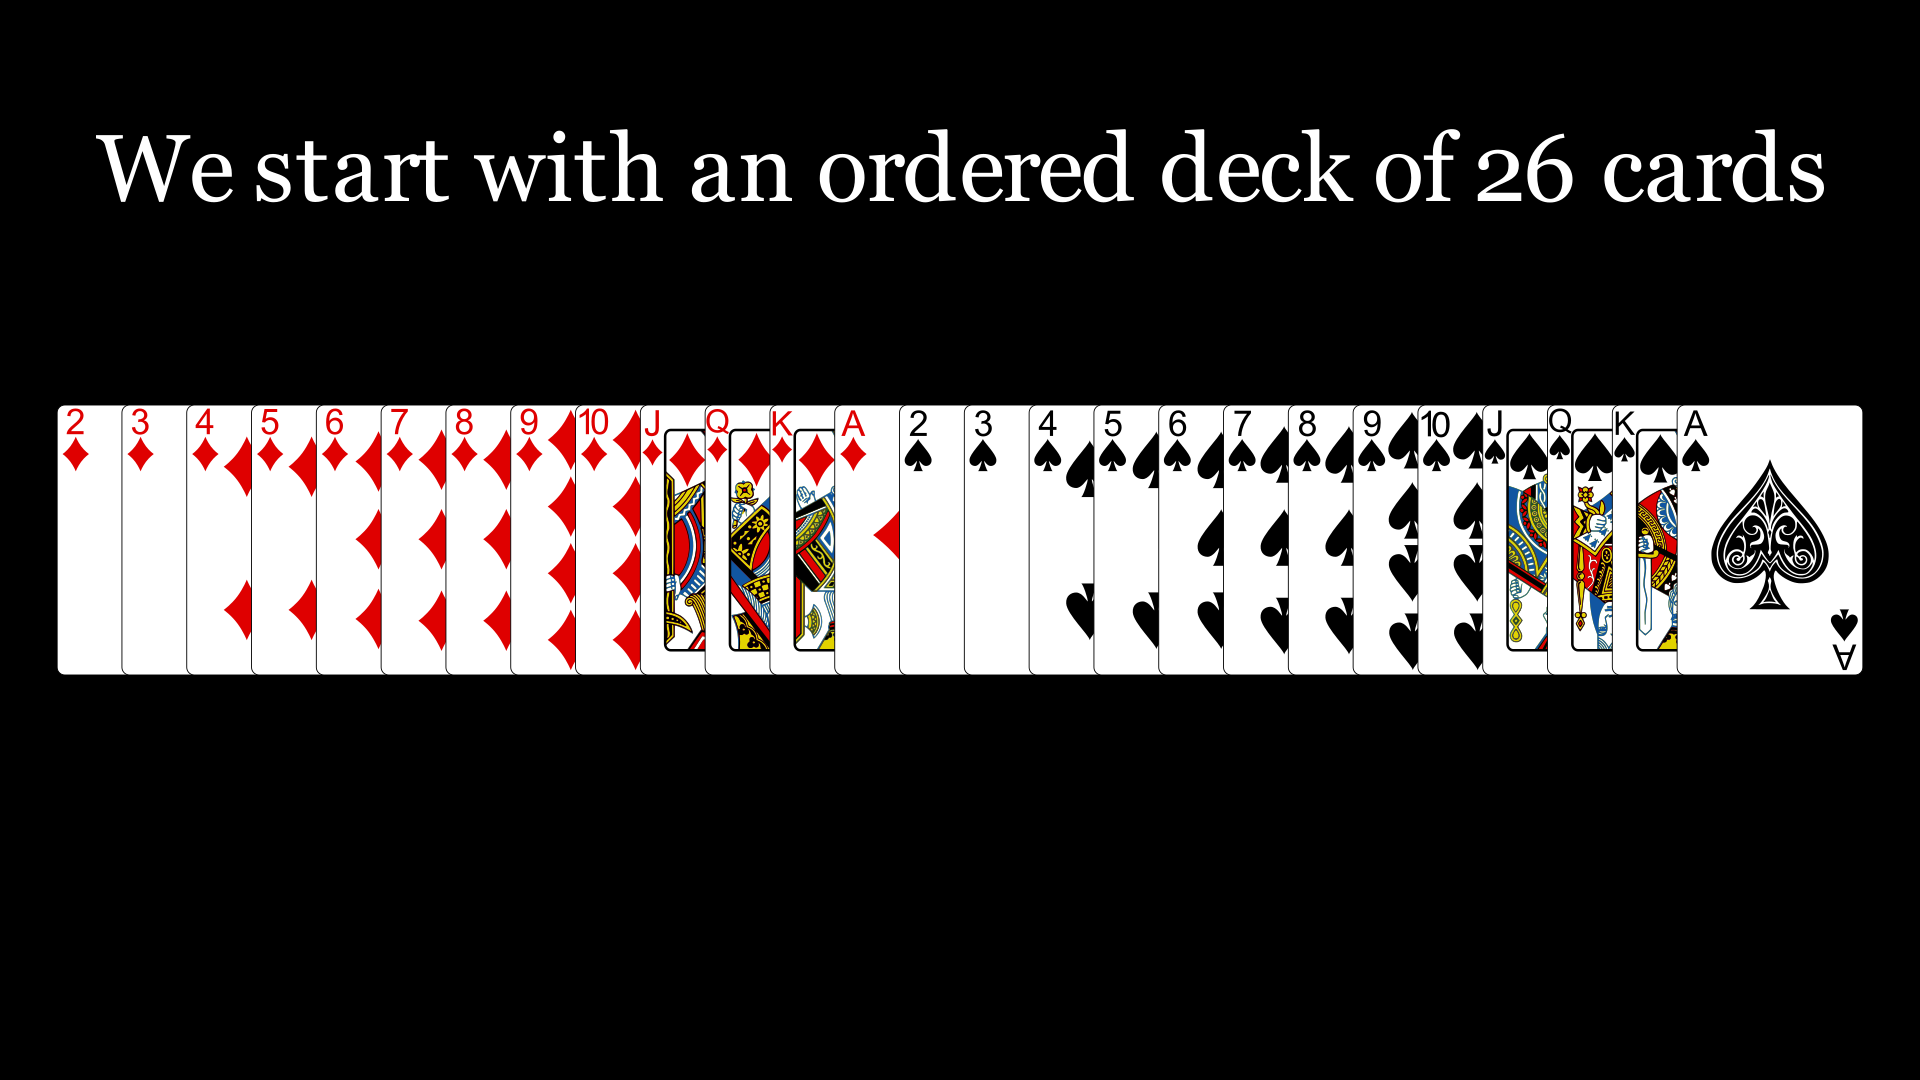

In [3]:
%%manim -qh ShowCards
class ShowCards(mn.Scene):
    def construct(self):
        x_min, x_max = -6, 6
        cards_positions = np.linspace(x_min, x_max, n_cards)

        cards = mn.VGroup()

        for n, pos in enumerate(cards_positions):
            card = mn.SVGMobject(f"images/cards/{cards_deck[n+1]}.svg")
            card.move_to([pos, 0, 0])
            cards.add(card)

        self.add(cards)

        label = mn.Text(f"We start with an ordered deck of {n_cards} cards")
        label.scale_to_fit_width(mn.config.frame_width * 0.9)
        label.next_to(cards, mn.UP, buff=1.5)
        self.add(label)

In [4]:
# Create a shuffling process (modular multiplication) based on the number of cards
def deck_shuffling_matrix(N):
    # Choose a random a such that gcd(a, N) = 1
    possible_as = list(range(2, N-2))
    random.shuffle(possible_as)
    for a in possible_as:
        if np.gcd(a, N) == 1:
            break
    # Modular multiplication M(a, N)
    M = np.zeros((N,N))
    for i in range(N):
        for j in range(N):
            if (a*j)%N==i:
                M[i][j] = 1
    return M

M = deck_shuffling_matrix(N)

In [5]:
%%manim -qh ShuffleCards
class ShuffleCards(mn.Scene):
    def prepare(self):
        x_min, x_max = -6, 6
        self.cards_positions = np.linspace(x_min, x_max, n_cards)
        self.original_order = sorted(list(cards_deck.keys()))
        self.current_order = self.original_order.copy()
        self.count = 0

    def display_text(self, text, next_to, direction, buff_value, set_max_width=False):
        label = mn.Text(text)
        if set_max_width:
            label.scale_to_fit_width(mn.config.frame_width * 0.9)
        label.next_to(next_to, direction, buff=buff_value)
        self.add(label)
        return label

    def display_cards(self, label_text):
        self.cards = mn.VGroup()
        for n, posx in enumerate(self.cards_positions):
            card = mn.SVGMobject(f"images/cards/{cards_deck[n+1]}.svg")
            card.move_to([posx, 0, 0])
            card.add_updater(
                lambda m: m.set_z_index(m.get_x())
            )
            self.cards.add(card)
        self.add(self.cards)
        label = self.display_text(label_text, self.cards, mn.UP, 1.5, set_max_width=True)
        self.wait(3)
        return label

    def shuffle_cards(self):
        self.current_order = M@self.current_order
        shuffled_positions = [self.cards_positions[self.current_order.tolist().index(n+1)-1] for n in range(n_cards)]
        animations =[
            mn.MoveAlongPath(
                card,
                mn.ArcBetweenPoints(
                    card.get_center(),
                    [new_x, 0, 0],
                    angle=0.25,
                ),
            )
            for card, new_x in zip(self.cards, shuffled_positions)
        ]
        self.play(*animations, run_time=2)
        self.count += 1
        self.remove(self.count_label)
        self.count_label = self.display_text(f"x = {self.count}", self.main_label, mn.DOWN, 0.5)
        self.wait(1)

    def construct(self):
        self.prepare()

        first_label = self.display_cards(f"Shuffling with modular multiplication contains a cycle")

        self.main_label = mn.Text("The cards go back to their original places after shuffling x times")
        self.main_label.scale_to_fit_width(mn.config.frame_width * 0.9)
        self.main_label.next_to(self.cards, mn.UP, buff=1.5)
        self.play(mn.ReplacementTransform(first_label, self.main_label))
        self.count_label = self.display_text(f"x = {self.count}", self.main_label, mn.DOWN, 0.5)
        self.wait(4)

        self.shuffle_cards()
        while (self.current_order != self.original_order).any():
            self.shuffle_cards()
        
        self.remove(self.count_label)
        self.count_label = self.display_text(f"x = {self.count}", self.main_label, mn.DOWN, 0.5)
        self.wait(3)

Manim Community v0.21.0

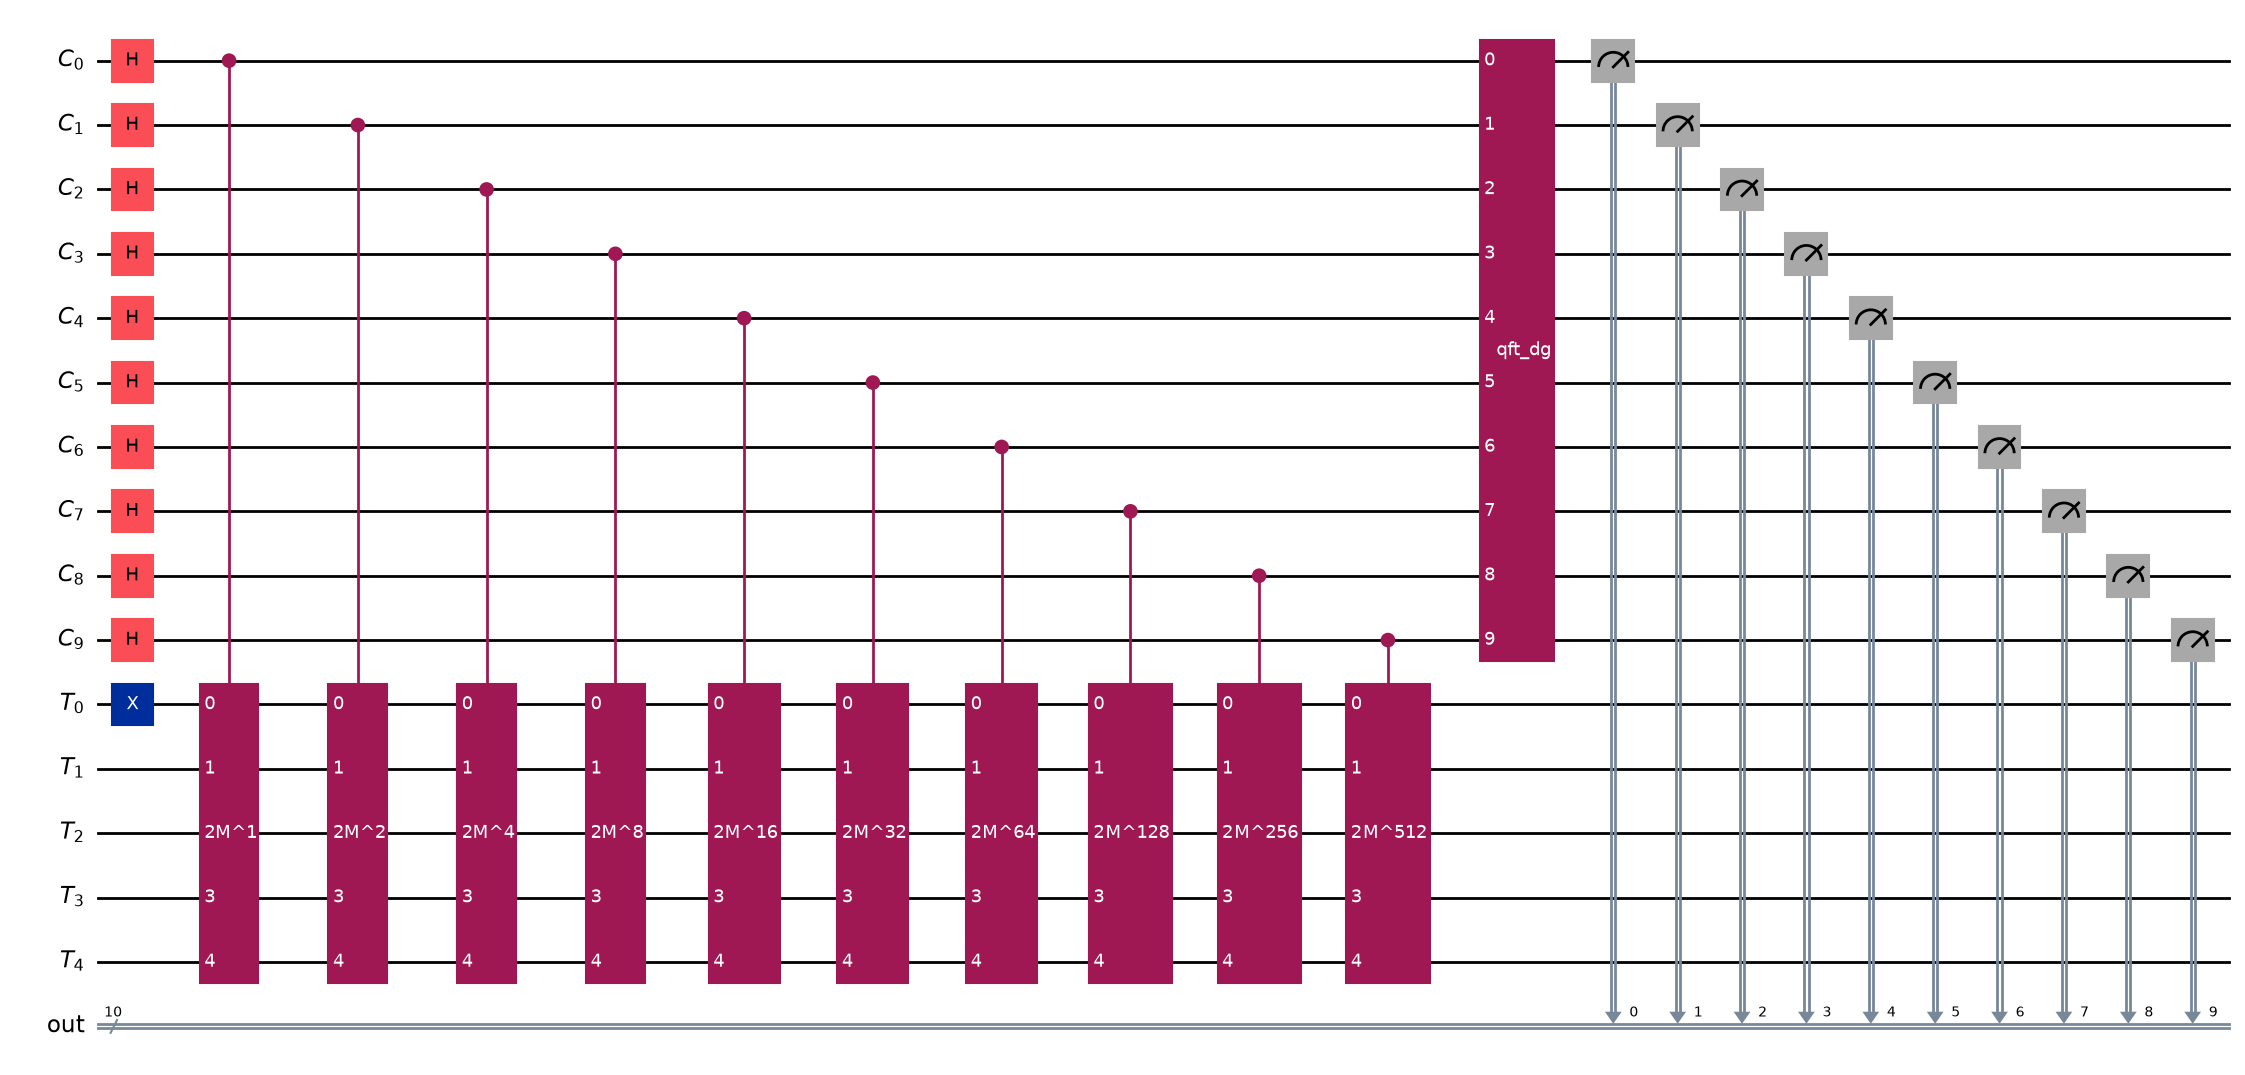

In [6]:
# Build the quantum circuit
n_target_qubits = int(np.ceil(np.log2(N)))
n_control_qubits = 2*n_target_qubits

control_register = QuantumRegister(n_control_qubits, name="C")
target_register = QuantumRegister(n_target_qubits, name="T")
output = ClassicalRegister(n_control_qubits, name="out")
circuit = QuantumCircuit(control_register, target_register, output)

circuit.x(target_register[0])

for m, qubit in enumerate(control_register):
    circuit.h(qubit)
    U_m = np.linalg.matrix_power(M, 2**m)
    U = np.eye(2**n_target_qubits)
    U[:N, :N] = U_m
    U_gate = UnitaryGate(U, label=f"M^{2**m}")
    circuit.compose(U_gate.control(), qubits=[qubit] + list(target_register), inplace=True)

circuit.compose(QFTGate(n_control_qubits).inverse(), qubits=control_register, inplace=True)

circuit.measure(control_register, output)

circuit.draw("mpl", fold=-1)

In [7]:
# Simulate the results
sim = AerSimulator()
tcircuit = transpile(circuit, sim)
result = sim.run(tcircuit).result()
counts = result.get_counts()

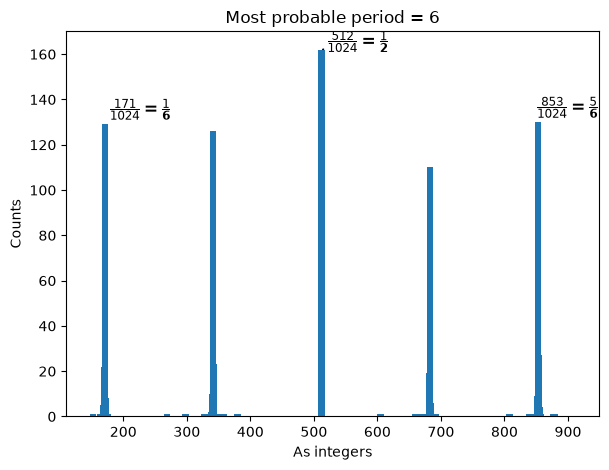

In [8]:
# Post-processing to find the shuffling period
counts_int = {int(k, 2): v for k, v in counts.items() if int(k, 2) != 0}
sorted_counts = np.array(sorted(counts_int.items()))
most_frequent_results = sorted_counts[:, 0][np.argsort(sorted_counts[:, 1])[-3:]]
possible_periods = {}
for i in most_frequent_results:
    frac = Fraction(i, 2**n_control_qubits)
    possible_periods[int(i)] = frac.limit_denominator(N)
most_frequent_periods = [frac.denominator for frac in possible_periods.values()]
most_probable_period = max(set(most_frequent_periods), key=most_frequent_periods.count)

# Plot the results
plt.figure()
plt.title(f"Most probable period = {most_probable_period}")
bars = plt.bar(sorted_counts[:, 0].astype(float), sorted_counts[:, 1].astype(float), width=10)
plt.xlabel('As integers')
plt.ylabel('Counts')
texts = []
for n in most_frequent_results:
    s = rf"$\frac{{{n}}}{{{2**n_control_qubits}}} = \frac{{{possible_periods[n].numerator}}}{{\mathbf{{{possible_periods[n].denominator}}}}}$"
    texts.append(plt.text(n, counts_int[n], s, fontsize=12))
plt.tight_layout()
adjust_text(
    texts,
    x=sorted_counts[:, 0],
    y=sorted_counts[:, 1],
    objects=bars,
    arrowprops=dict(arrowstyle="->", lw=0.8),
    expand_axes=True,
    force_text=(0.3, 0.3),
    force_static=(0.3, 0.3),
)
plt.show()